In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph , START ,END

In [2]:
class AgentState(TypedDict):
    number1 : int
    number2 : int
    operator1 : str
    answer1 : int
    
    number3 : int
    number4 : int
    operator2 : str
    answer2 : int

In [3]:
def adder1(state:AgentState)-> AgentState:
    state['answer1'] = state['number1'] + state['number2']
    return state
def subtract1(state:AgentState)->AgentState:
    state['answer1'] = state['number1'] - state['number2']
    return state

def decide_1st_calc(state:AgentState)->str:
    if state['operator1']== "+":
        return "addition_operation1"
    elif state['operator1'] == "-":
        return "subtraction_operation1"
    
p=subtract1(AgentState(number1=2,number2=4))
p

{'number1': 2, 'number2': 4, 'answer1': -2}

In [4]:
def adder2(state:AgentState)-> AgentState:
    state['answer2'] = state['number3'] + state['number4']
    return state
def subtract2(state:AgentState)->AgentState:
    state['answer2'] = state['number3'] - state['number4']
    return state

def decide_2nd_calc(state:AgentState)->str:
    if state['operator2']== "+":
        return "addition_operation2"
    elif state['operator2'] == "-":
        return "subtraction_operation2"
q=adder2(AgentState(number3=2,number4=4))
q

{'number3': 2, 'number4': 4, 'answer2': 6}

In [9]:
graph = StateGraph(AgentState)

graph.add_node("add_node",adder1)
graph.add_node("subtract_node",subtract1)
graph.add_node("router",lambda state:state)
graph.add_edge(START,'router')
graph.add_conditional_edges(
    'router',
    decide_1st_calc,
    { #str:node
        "addition_operation1":"add_node",
        "subtraction_operation1":"subtract_node"
    }
)
graph.add_edge("add_node",'router2')
graph.add_edge("subtract_node",'router2')

graph.add_node("add2_node",adder2)
graph.add_node("subtract2_node",subtract2)
graph.add_node("router2",lambda state:state)

graph.add_conditional_edges(
    'router2',
    decide_2nd_calc,
    {#str:node
        "addition_operation2":"add2_node",
        "subtraction_operation2":"subtract2_node"
    }
)
graph.add_edge("add2_node",END)
graph.add_edge("subtract2_node",END)

In [10]:
app = graph.compile()

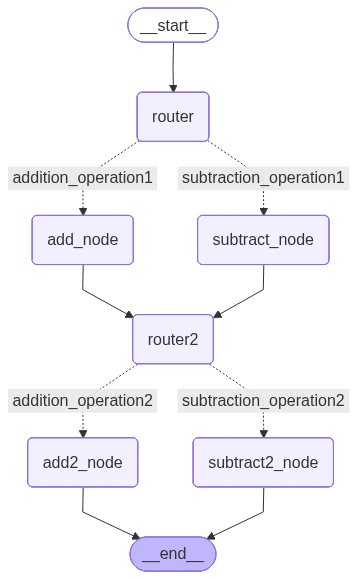

In [7]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [8]:
trail1 = AgentState(number1=2,number2=4,operator1="+",number3=5,number4=3,operator2="-")
print(app.invoke(trail1))

{'number1': 2, 'number2': 4, 'operator1': '+', 'answer1': 6, 'number3': 5, 'number4': 3, 'operator2': '-', 'answer2': 2}
